## Initial backtest results

### Load the summary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet

In [5]:
summary = load_parquet(
    PROCESSED_DATA_DIR / "factor_backtest_summary.parquet"
)

summary

,factor,observations,total_return,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown,positive_day_fraction,average_daily_turnover,average_rebalance_turnover,total_transaction_cost,maximum_missing_return_weight
0,12-1 Momentum,2890.0,0.237925,0.018785,0.211280,0.194719,-0.490626,0.491349,0.087855,0.439273,0.2539,0.0
1,Realised Volatility,2890.0,4.371090,0.157869,0.239941,0.731003,-0.452815,0.519723,0.068962,0.344810,0.1993,0.0


### Load daily results

In [6]:
momentum_daily = load_parquet(
    PROCESSED_DATA_DIR
    / "backtest_12_1_momentum_daily.parquet"
)

volatility_daily = load_parquet(
    PROCESSED_DATA_DIR
    / "backtest_realised_volatility_daily.parquet"
)

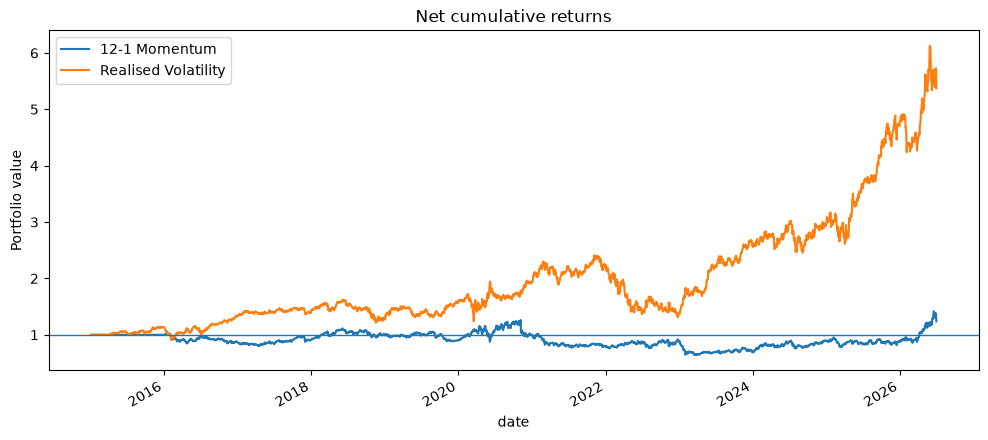

In [4]:
ax = momentum_daily.plot(
    x="date",
    y="net_cumulative_return",
    figsize=(12, 5),
    label="12-1 Momentum",
)

volatility_daily.plot(
    x="date",
    y="net_cumulative_return",
    ax=ax,
    label="Realised Volatility",
)

ax.set_title("Net cumulative returns")
ax.set_ylabel("Portfolio value")
ax.axhline(1.0, linewidth=1)

In [5]:
momentum_daily[
    [
        "gross_cumulative_return",
        "net_cumulative_return",
    ]
].tail()

,gross_cumulative_return,net_cumulative_return
2885,1.680704,1.303847
2886,1.727902,1.340463
2887,1.778395,1.379634
2888,1.678252,1.301946
2889,1.595727,1.237925


In [6]:
momentum_daily.loc[
    momentum_daily["is_rebalance"],
    ["date", "turnover", "transaction_cost"],
].describe()

,date,turnover,transaction_cost
count,578,578.000000,578.000000
mean,2020-09-25 18:48:34.878000,0.439273,0.000439
min,2015-01-02 00:00:00,0.000000,0.000000
25%,2017-11-10 18:00:00,0.300000,0.000300
50%,2020-09-25 12:00:00,0.400000,0.000400
75%,2023-08-08 06:00:00,0.600000,0.000600
max,2026-06-25 00:00:00,2.000000,0.002000
std,NaN,0.231409,0.000231


In [7]:
volatility_daily.loc[
    volatility_daily["is_rebalance"],
    ["date", "turnover", "transaction_cost"],
].describe()

,date,turnover,transaction_cost
count,578,578.000000,578.000000
mean,2020-09-25 18:48:34.878000,0.344810,0.000345
min,2015-01-02 00:00:00,0.000000,0.000000
25%,2017-11-10 18:00:00,0.200000,0.000200
50%,2020-09-25 12:00:00,0.300000,0.000300
75%,2023-08-08 06:00:00,0.500000,0.000500
max,2026-06-25 00:00:00,2.000000,0.002000
std,NaN,0.206184,0.000206


In [8]:
momentum_daily["missing_return_weight"].describe()

count    2890.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: missing_return_weight, dtype: float64

## Backtest robustness analysis
Include:
- Different rebalance offsets
- Long and short legs separately
- Subperiod performance


In [9]:
from alpha_research.backtest import (
    BacktestConfig,
    run_rebalance_offset_backtests,
    summarise_backtest_legs,
    summarise_backtest_subperiods,
)

In [10]:
input_path = PROCESSED_DATA_DIR / "factor_panel.parquet"

factor_panel = load_parquet(input_path)

### Rebalance-offset robustness

In [11]:
config = BacktestConfig(
    rebalance_frequency=5,
    transaction_cost_bps=10.0,
    min_observations=30,
)

offset_results = []

for factor_name, factor_column in {
    "12-1 Momentum": "mom_12_1m_z",
    "Realised Volatility": "realised_vol_63_z",
}.items():
    result = run_rebalance_offset_backtests(
        factor_panel,
        factor_column=factor_column,
        base_config=config,
    )

    result["factor"] = factor_name
    offset_results.append(result)

offset_summary = pd.concat(
    offset_results,
    ignore_index=True,
)

offset_summary[
    [
        "factor",
        "offset",
        "annualised_return",
        "annualised_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "average_rebalance_turnover",
    ]
]

,factor,offset,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown,average_rebalance_turnover
0,12-1 Momentum,0,0.018785,0.211280,0.194719,-0.490626,0.439273
1,12-1 Momentum,1,0.011130,0.211569,0.159069,-0.522562,0.444810
2,12-1 Momentum,2,0.013756,0.210859,0.171092,-0.485051,0.445156
3,12-1 Momentum,3,0.016735,0.211247,0.185098,-0.446205,0.442042
4,12-1 Momentum,4,0.018027,0.212701,0.191370,-0.458521,0.438754
5,Realised Volatility,0,0.157869,0.239941,0.731003,-0.452815,0.344810
6,Realised Volatility,1,0.162929,0.241360,0.746151,-0.425771,0.344464
7,Realised Volatility,2,0.160537,0.239850,0.740787,-0.432170,0.354152
8,Realised Volatility,3,0.157952,0.239445,0.732320,-0.436398,0.355363
9,Realised Volatility,4,0.159243,0.239972,0.735910,-0.436886,0.346194


### Leg decomposition

In [12]:
momentum_legs = summarise_backtest_legs(momentum_daily)
volatility_legs = summarise_backtest_legs(volatility_daily)

momentum_legs

,portfolio,total_return,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown,positive_day_fraction
0,long_leg,11.719155,0.248262,0.219442,1.121150,-0.336729,0.521107
1,short_leg,-0.906715,-0.186851,0.218839,-0.835076,-0.917881,0.426298
2,gross_long_short,0.595727,0.041592,0.211278,0.299508,-0.461783,0.495156
3,net_long_short,0.237925,0.018785,0.211280,0.194719,-0.490626,0.491349


In [13]:
volatility_legs

,portfolio,total_return,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown,positive_day_fraction
0,long_leg,20.779659,0.308201,0.282709,1.092459,-0.433375,0.543945
1,short_leg,-0.762931,-0.117955,0.137281,-0.845510,-0.788415,0.448789
2,gross_long_short,5.555869,0.178170,0.239893,0.803592,-0.444938,0.521799
3,net_long_short,4.371090,0.157869,0.239941,0.731003,-0.452815,0.519723


### Subperiod performance

In [14]:
periods = {
    "2015-2018": ("2015-01-01", "2018-12-31"),
    "2019-2022": ("2019-01-01", "2022-12-31"),
    "2023-present": ("2023-01-01", "2026-12-31"),
}

In [15]:
momentum_subperiods = summarise_backtest_subperiods(
    momentum_daily,
    periods=periods,
)

momentum_subperiods[
    [
        "period",
        "annualised_return",
        "annualised_volatility",
        "sharpe_ratio",
        "max_drawdown",
    ]
]

,period,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown
0,2015-2018,-0.002164,0.138149,0.053629,-0.223610
1,2019-2022,-0.028532,0.244062,0.005231,-0.398705
2,2023-present,0.102076,0.238478,0.527293,-0.271132


In [16]:
volatility_subperiods = summarise_backtest_subperiods(
    volatility_daily,
    periods=periods,
)

volatility_subperiods[
    [
        "period",
        "annualised_return",
        "annualised_volatility",
        "sharpe_ratio",
        "max_drawdown",
    ]
]

,period,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown
0,2015-2018,0.070962,0.157363,0.514657,-0.252887
1,2019-2022,0.008276,0.284894,0.170979,-0.452815
2,2023-present,0.484933,0.260507,1.649073,-0.186253


## Exposure diagnosis

### Load SPY data

In [2]:
from alpha_research.risk import (
    calculate_rolling_beta,
    calculate_sector_exposure,
    calculate_strategy_exposures,
    prepare_benchmark_returns,
    summarise_sector_exposure,
)
from alpha_research.config.paths import RAW_DATA_DIR

spy = load_parquet(
    RAW_DATA_DIR / "spy_benchmark.parquet"
)

In [3]:
# spy = spy.loc[spy["ticker"] == "SPY"].copy()
spy_returns = prepare_benchmark_returns(
    spy,
    price_column="adj_close",
)

spy_returns.head()

,date,benchmark_return
0,2015-01-02,-0.018060
1,2015-01-05,-0.009419
2,2015-01-06,0.012461
3,2015-01-07,0.017745
4,2015-01-08,-0.008014


### Calculate market exposure

In [7]:
momentum_market_exposure = calculate_strategy_exposures(
    momentum_daily,
    spy_returns,
)

volatility_market_exposure = calculate_strategy_exposures(
    volatility_daily,
    spy_returns,
)

In [8]:
momentum_market_exposure[
    [
        "portfolio",
        "beta",
        "annualised_alpha",
        "correlation",
        "r_squared",
        "annualised_residual_volatility",
    ]
]

,portfolio,beta,annualised_alpha,correlation,r_squared,annualised_residual_volatility
0,long_leg,1.042091,0.100406,0.838061,0.702347,0.119722
1,short_leg,-0.976845,-0.040971,-0.787752,0.620553,0.134804
2,gross_long_short,0.065246,0.055338,0.054499,0.002970,0.210964
3,net_long_short,0.065381,0.032214,0.054611,0.002982,0.210964


In [9]:
volatility_market_exposure[
    [
        "portfolio",
        "beta",
        "annualised_alpha",
        "correlation",
        "r_squared",
        "annualised_residual_volatility",
    ]
]

,portfolio,beta,annualised_alpha,correlation,r_squared,annualised_residual_volatility
0,long_leg,1.420334,0.109526,0.886625,0.786103,0.130750
1,short_leg,-0.599198,-0.029200,-0.770282,0.593335,0.087544
2,gross_long_short,0.821137,0.077140,0.604069,0.364900,0.191178
3,net_long_short,0.821521,0.058529,0.604231,0.365096,0.191187


### Rolling beta

Text(0, 0.5, 'Beta to SPY')

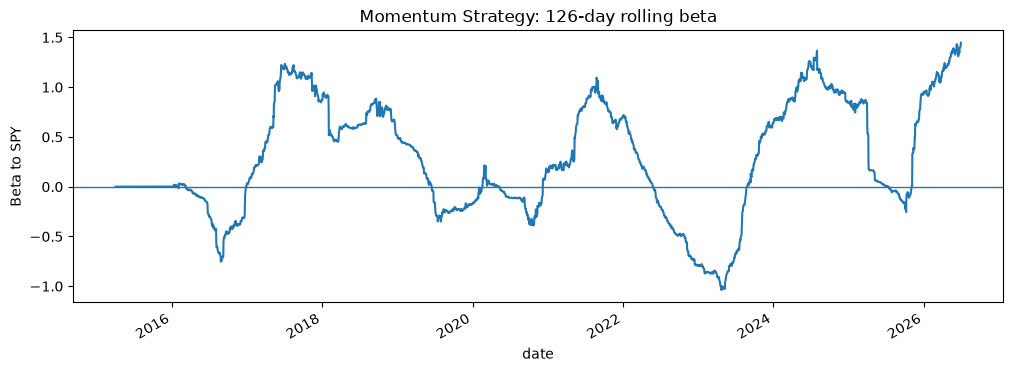

In [10]:
momentum_rolling_beta = calculate_rolling_beta(
    momentum_daily,
    spy_returns,
    strategy_return_column="net_return",
    window=126,
    min_periods=63,
)

ax = momentum_rolling_beta.plot(
    x="date",
    y="rolling_beta_126",
    figsize=(12, 4),
    title="Momentum Strategy: 126-day rolling beta",
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Beta to SPY")

In [11]:
momentum_rolling_beta.describe()

,date,net_return,benchmark_return,rolling_beta_126
count,2890,2890.000000,2890.000000,2828.000000
mean,2020-09-28 17:08:25.743000,0.000163,0.000572,0.277799
min,2015-01-02 00:00:00,-0.155128,-0.109423,-1.038127
25%,2017-11-13 06:00:00,-0.005698,-0.003703,-0.112173
50%,2020-09-28 12:00:00,0.000000,0.000654,0.188265
75%,2023-08-13 06:00:00,0.006949,0.005930,0.785848
max,2026-07-01 00:00:00,0.058871,0.105019,1.446358
std,NaN,0.013309,0.011117,0.570363


Text(0, 0.5, 'Beta to SPY')

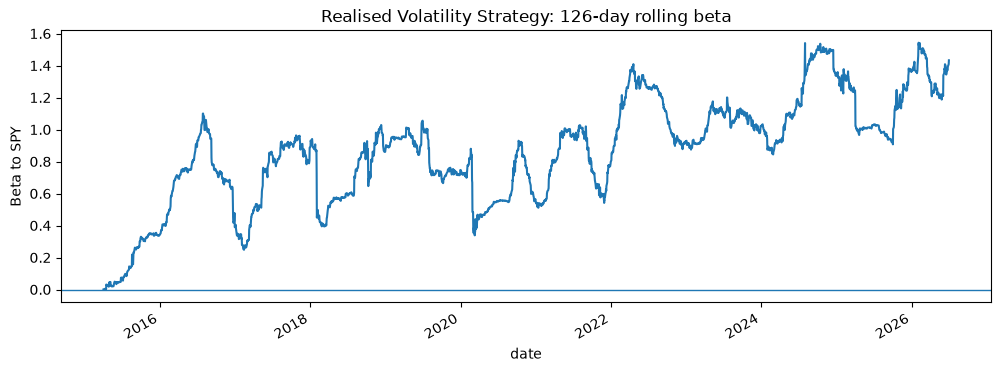

In [12]:
volatility_rolling_beta = calculate_rolling_beta(
    volatility_daily,
    spy_returns,
    strategy_return_column="net_return",
    window=126,
    min_periods=63,
)

ax = volatility_rolling_beta.plot(
    x="date",
    y="rolling_beta_126",
    figsize=(12, 4),
    title="Realised Volatility Strategy: 126-day rolling beta",
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Beta to SPY")

In [13]:
volatility_rolling_beta.describe()

,date,net_return,benchmark_return,rolling_beta_126
count,2890,2890.000000,2890.000000,2828.000000
mean,2020-09-28 17:08:25.743000,0.000696,0.000572,0.861944
min,2015-01-02 00:00:00,-0.078530,-0.109423,-0.003086
25%,2017-11-13 06:00:00,-0.006631,-0.003703,0.664020
50%,2020-09-28 12:00:00,0.000502,0.000654,0.904906
75%,2023-08-13 06:00:00,0.008516,0.005930,1.057505
max,2026-07-01 00:00:00,0.104698,0.105019,1.542679
std,NaN,0.015115,0.011117,0.328508


### Sector exposure

In [31]:
momentum_holdings = load_parquet(
    PROCESSED_DATA_DIR
    / "backtest_12_1_momentum_holdings.parquet"
)

volatility_holdings = load_parquet(
    PROCESSED_DATA_DIR
    / "backtest_realised_volatility_holdings.parquet"
)

In [32]:
metadata = (
    factor_panel[
        ["ticker", "sector"]
    ]
    .drop_duplicates(subset=["ticker"])
)

In [33]:
momentum_rebalance_dates = momentum_daily.loc[
    momentum_daily["is_rebalance"],
    "date",
]

volatility_rebalance_dates = volatility_daily.loc[
    volatility_daily["is_rebalance"],
    "date",
]

In [34]:
momentum_sector_exposure = calculate_sector_exposure(
    momentum_holdings,
    metadata,
    rebalance_dates=momentum_rebalance_dates,
)

volatility_sector_exposure = calculate_sector_exposure(
    volatility_holdings,
    metadata,
    rebalance_dates=volatility_rebalance_dates,
)

In [35]:
momentum_sector_summary = summarise_sector_exposure(
    momentum_sector_exposure
)

volatility_sector_summary = summarise_sector_exposure(
    volatility_sector_exposure
)

In [36]:
momentum_sector_summary.head(10)

,sector,average_long_weight,average_short_weight,average_net_weight,average_gross_weight,maximum_absolute_net_weight
0,Information Technology,0.299913,0.145934,0.153979,0.445848,0.60
1,Health Care,0.116436,0.159170,-0.042734,0.275606,0.45
2,Industrials,0.112197,0.131401,-0.019204,0.243599,0.35
3,Financials,0.109775,0.117128,-0.007353,0.226903,0.55
4,Communication Services,0.087284,0.094377,-0.007093,0.181661,0.30
5,Consumer Discretionary,0.078633,0.084083,-0.005450,0.162716,0.30
6,Consumer Staples,0.048270,0.086246,-0.037976,0.134516,0.35
7,Energy,0.024913,0.043080,-0.018166,0.067993,0.15
8,Utilities,0.018339,0.025173,-0.006834,0.043512,0.15
9,Real Estate,0.012976,0.023356,-0.010381,0.036332,0.10


In [37]:
volatility_sector_summary.head(10)

,sector,average_long_weight,average_short_weight,average_net_weight,average_gross_weight,maximum_absolute_net_weight
0,Information Technology,0.438581,0.044464,0.394118,0.483045,0.80
1,Consumer Staples,0.008478,0.280363,-0.271886,0.288841,0.45
2,Health Care,0.072664,0.174221,-0.101557,0.246886,0.45
3,Industrials,0.116869,0.094550,0.022318,0.211419,0.30
4,Financials,0.088235,0.112889,-0.024654,0.201125,0.40
5,Consumer Discretionary,0.128720,0.059429,0.069291,0.188149,0.25
6,Communication Services,0.083824,0.074740,0.009083,0.158564,0.25
7,Utilities,0.001211,0.085727,-0.084516,0.086938,0.15
8,Energy,0.030969,0.015484,0.015484,0.046453,0.15
9,Real Estate,0.007958,0.017820,-0.009862,0.025779,0.10
